In [2]:
%matplotlib notebook

import numpy as np
import pandas as pd

from scipy.optimize import leastsq
from matplotlib import pyplot as plt

from thermo import *

In [3]:
mt = load_melt('./data/2021-05-12_110813_MeltCurve Data.txt')
wt = load_melt('./data/MproWT_thermal_melt_MeltCurve Data.txt')

mdf = pd.DataFrame(mt)
wt  = pd.DataFrame(wt)

In [4]:
# Column key:
#  4,5,6 --> N214A
#  7,8,9 --> Q256A
#  10,11,12 --> S284A
#  [10,11,12 --> wt]

def expand_cols(cols):
    
    rows = ['B', 'C', 'D', 'E', 'F', 'G', 'H']
    wells = []
    
    
    for row in rows:
        for col in cols:
            wells.append('%s%d' % (row, col))
    
    return wells

wt = wt[['temperature'] + expand_cols([10,11,12])]

n214a = mdf[['temperature'] + expand_cols([4,5,6])]
q256a = mdf[['temperature'] + expand_cols([7,8,9])]
s284a = mdf[['temperature'] + expand_cols([10,11,12])]
s284a

,temperature,B10,B11,B12,C10,C11,C12,D10,D11,D12,...,E12,F10,F11,F12,G10,G11,G12,H10,H11,H12
0,24.897,-1098.954,-1564.976,-618.924,-348.869,-338.711,517.357,1435.310,-1207.398,111.040,...,325.082,-253.257,483.891,444.225,217.700,782.906,563.208,464.025,245.901,-164.569
1,25.011,-890.154,-1353.480,-461.653,-281.453,-232.515,558.170,1392.753,-1074.459,103.180,...,324.697,-206.889,463.954,446.833,228.328,750.280,573.810,437.136,244.855,-155.896
2,25.125,-639.355,-1077.757,-251.014,-204.437,-120.040,607.032,1329.926,-944.836,87.701,...,320.442,-171.670,437.134,431.840,236.488,700.846,585.243,421.307,234.132,-144.614
3,25.239,-364.756,-748.355,2.542,-112.035,-0.233,667.449,1251.649,-817.998,71.603,...,315.983,-143.958,407.261,398.877,241.815,638.054,589.646,412.546,216.164,-125.865
4,25.354,-92.932,-398.661,266.882,4.011,127.311,737.898,1171.976,-690.746,65.544,...,314.792,-115.302,381.364,356.036,243.009,573.773,578.357,403.236,197.811,-95.586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,94.330,108.333,1243.679,495.658,-153.985,-1395.548,-775.137,197.975,951.299,-882.856,...,1645.185,2787.544,3140.255,3630.011,3191.606,2169.462,2969.942,1438.210,1830.571,1410.522
609,94.444,126.796,1201.112,443.758,-102.516,-1433.528,-753.562,173.179,984.088,-934.205,...,288.780,2699.867,3019.230,3712.030,3119.868,2085.274,3173.663,1379.254,1869.550,1539.055
610,94.558,121.152,1135.951,374.498,-97.392,-1422.542,-731.205,158.000,1011.915,-945.700,...,-1124.508,2707.168,2998.111,3764.062,3091.102,2020.374,3386.248,1310.176,1920.062,1659.581
611,94.672,95.417,1058.284,291.018,-139.515,-1385.728,-732.271,140.641,1037.332,-928.242,...,-2468.761,2772.703,3033.710,3774.581,3114.709,1955.377,3553.396,1252.918,1961.493,1743.605


<IPython.core.display.Javascript object>


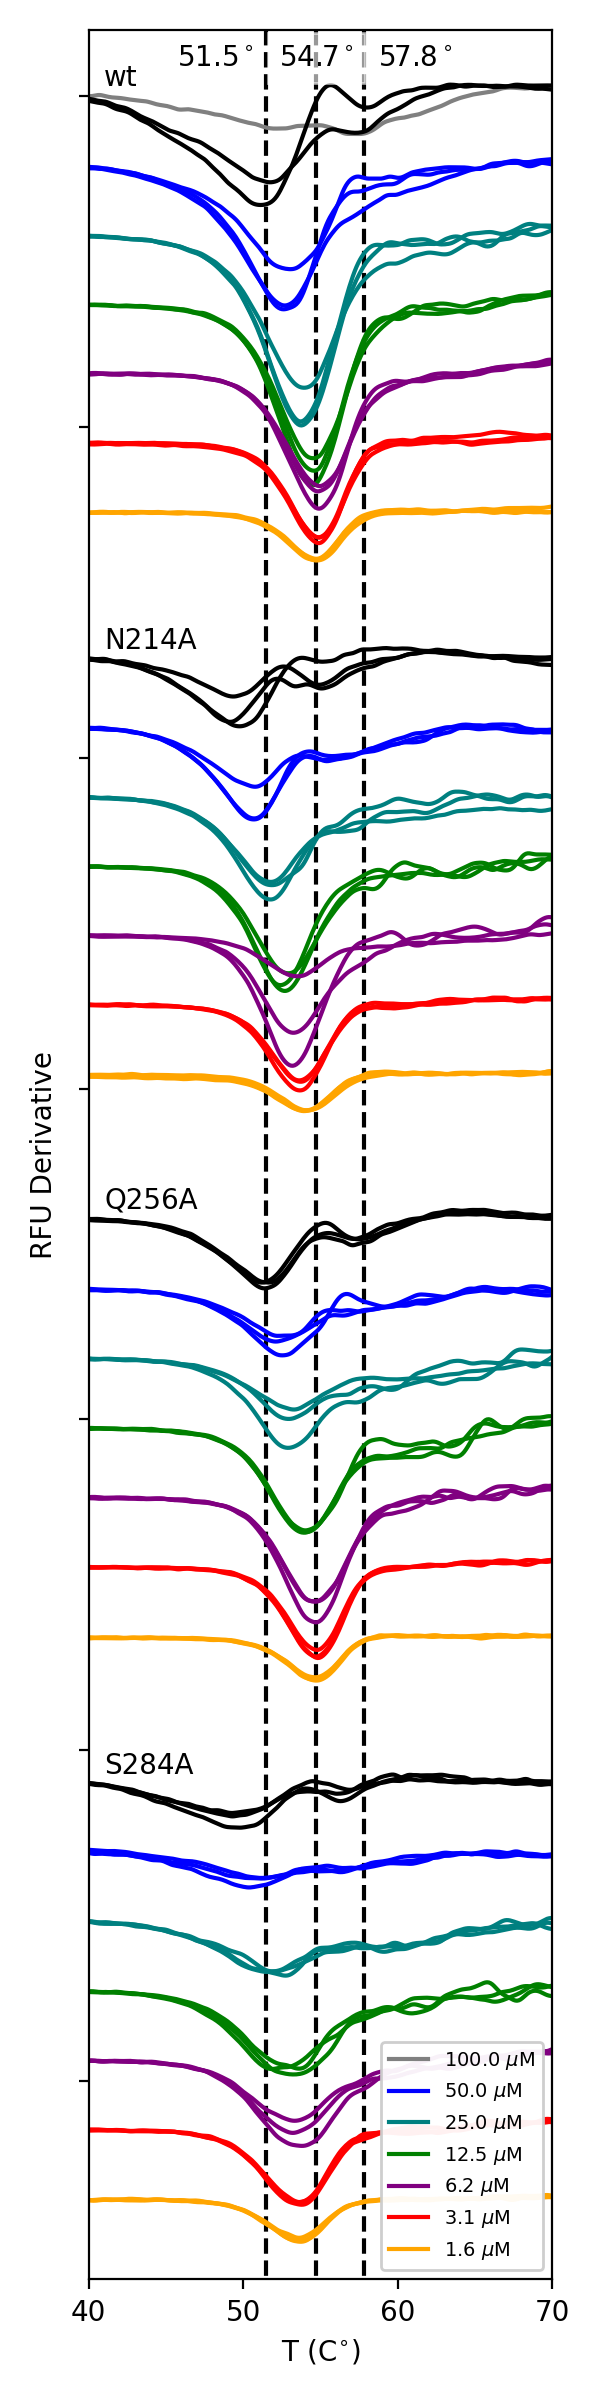

In [5]:
high_T_cutoff = 400
n_repeats     = 3

datasets = ['wt', 'N214A', 'Q256A', 'S284A']
colors = ['k', 'b', 'teal', 'green', 'purple', 'r', 'orange']



minima = np.zeros([ len(datasets), 7, n_repeats ])

plt.figure(figsize=(3,12))
ax = plt.subplot(111)

for idf, df in enumerate([wt, n214a, q256a, s284a]):
    
    T = df.to_numpy()[:high_T_cutoff,0]
    x = df.to_numpy()[:high_T_cutoff,1:]
    n_conc = x.shape[1]//n_repeats
    
    for i in range(n_conc):        
        offset = i * 21000 + idf * 170000

        if i == 1:
            plt.text(41, x[0,i*n_repeats] - offset + 24000, datasets[idf])
        
        for j in range(n_repeats):
            if j == 0 and idf == 0:
                mylabel = '%.1f $\mu$M' % (100.0/(2**i),)
            else:
                mylabel = '_no_legend_'
            
            if i == 0 and j == 0 and idf == 0: # outlier
                color = 'grey'
            else:
                color = colors[i]
            
            ax.plot(T, x[:,i*n_repeats + j] - offset, 
                    color=color, label=mylabel)
            
            minima[idf, i, j] = T[ np.argmin(x[:,i*n_repeats + j]) ]


ax.set_yticklabels([])
plt.xlim([40, 70])
plt.ylim([-660000, 20000])
            
plt.xlabel('T (C$^{\circ}$)')
plt.ylabel('RFU Derivative')

plt.vlines([51.5, 54.7, 57.8], 20000, -660000, 'k', linestyle='dashed')
plt.text(45.7, 9000, '51.5$^\circ$')
plt.text(52.3, 9000, '54.7$^\circ$', bbox=dict(facecolor='white', alpha=0.6, ec='white'))
plt.text(58.7, 9000, '57.8$^\circ$')

plt.legend(loc=4, fontsize=7, framealpha=0.95)

plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


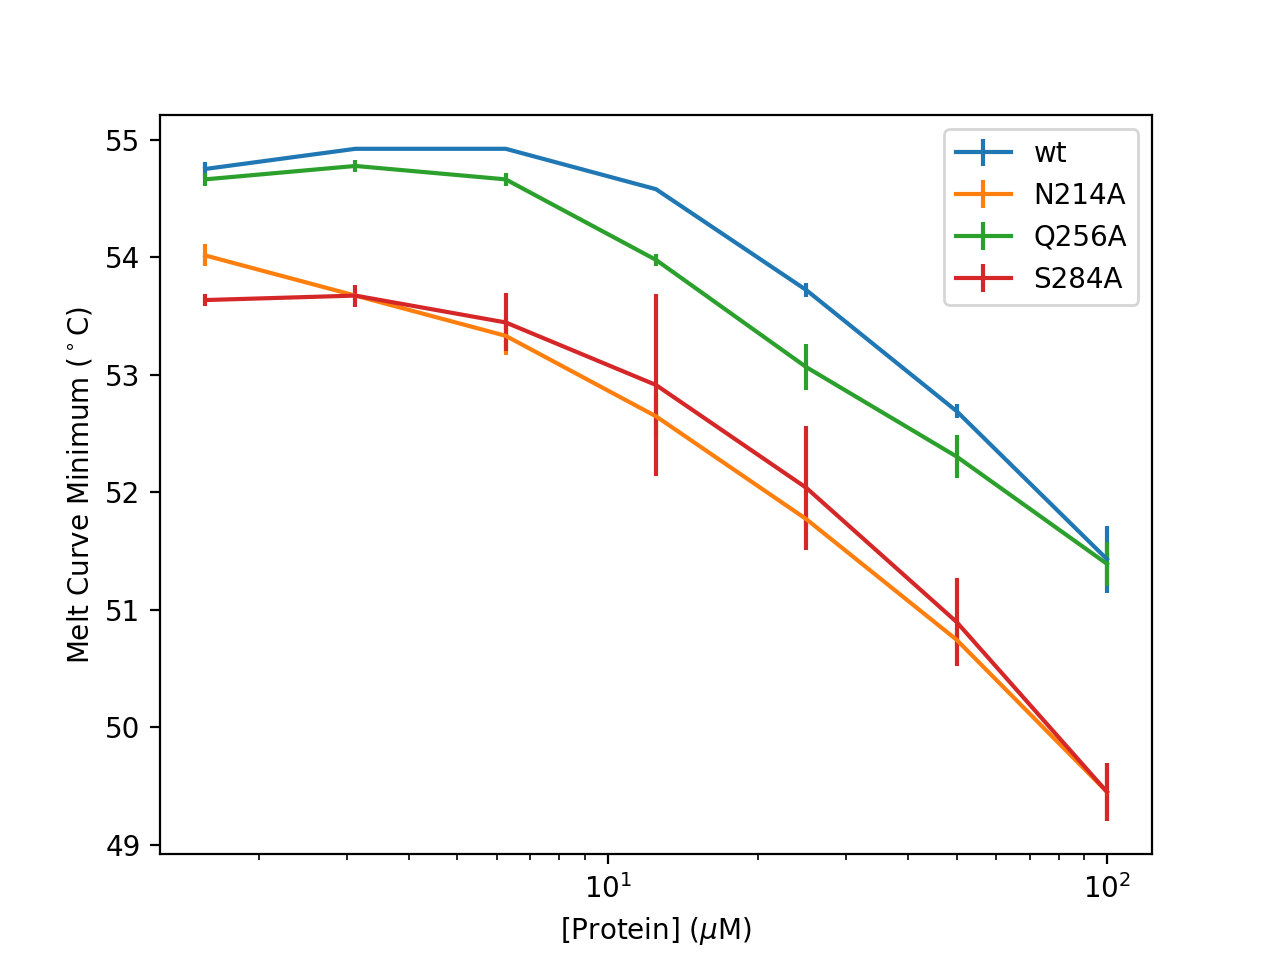

In [6]:
concs = [ 100.0/(2**i) for i in range(7) ]

plt.figure()
for i in range(4):
    if i == 0:
        # discard first trace as an outlier
        plt.errorbar(concs, minima[i,:,1:].mean(1), yerr=minima[i,:,1:].std(1))
    else:
        plt.errorbar(concs, minima[i].mean(1), yerr=minima[i].std(1))
    
plt.xlabel('[Protein] ($\mu$M)')
plt.ylabel('Melt Curve Minimum ($^\circ$C)')

plt.legend(datasets)

plt.xscale('log')
plt.show()